In [ ]:
# ── Cell 1: Install and RESTART ───────────────────────────────────────────
import os
import sys

# Force numpy downgrade
os.system('pip install numpy==1.26 transformer-lens -q')

# Auto-restart runtime to clear memory
print('Restarting runtime to apply numpy fix...')
os.kill(os.getpid(), 9)

In [1]:
# ── Cell 2: Clone repo and pull latest ───────────────────────────────────
!git clone https://github.com/Lucianavv/ioi-circuit-analysis.git 2>/dev/null || echo 'Already cloned'
%cd ioi-circuit-analysis
!git pull origin main
print('Repo ready')

Already cloned
/content/ioi-circuit-analysis
From https://github.com/Lucianavv/ioi-circuit-analysis
 * branch            main       -> FETCH_HEAD
Already up to date.
Repo ready


In [2]:
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt
import json

sys.path.insert(0, '/content/ioi-circuit-analysis')

from src.ioi_dataset import (
    generate_ioi_dataset, create_corrupted_prompt,
    load_dataset, save_dataset, SINGLE_TOKEN_NAMES
)
from src.metrics import (
    compute_logit_difference, evaluate_dataset
)
from src.patching import (
    path_patch_head, mean_ablate_head, get_mean_head_activation
)
from src.acdc import run_acdc, compute_circuit_overlap
from src.attribution_patching import run_attribution_patching, scores_to_grid
from src.validation import run_full_validation, KNOWN_IOI_HEADS, ALL_KNOWN_HEADS

print('All imports successful')

All imports successful


In [3]:
# Verify GPU is available
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
if device == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
GPU: Tesla T4
Memory: 15.6 GB


In [4]:
from transformer_lens import HookedTransformer

model = HookedTransformer.from_pretrained(
    'gpt2',
    center_unembed=True,
    center_writing_weights=True,
    fold_ln=True
)
model = model.to('cuda')
model.eval()

print(f'GPT-2 Small loaded')
print(f'  Layers: {model.cfg.n_layers}')
print(f'  Heads:  {model.cfg.n_heads}')
print(f'  d_model: {model.cfg.d_model}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Loaded pretrained model gpt2 into HookedTransformer
Moving model to device:  cuda
GPT-2 Small loaded
  Layers: 12
  Heads:  12
  d_model: 768


In [5]:
dataset = load_dataset('data/prompts/ioi_baseline_dataset.json')
print(f'Loaded {len(dataset)} prompts')

# Sanity check
sample = dataset[0]
diff, _, _ = compute_logit_difference(
    model,
    sample['prompt'],
    sample['correct_answer'],
    sample['incorrect_answer']
)
print(f'\nSample prompt:    {sample["prompt"]}')
print(f'Correct answer:   {sample["correct_answer"]}')
print(f'Logit difference: {diff:.3f} (should be positive)')
print(f'Stored baseline:  {sample["baseline_logit_diff"]:.3f} (should match)')

Loaded 100 prompts

Sample prompt:    When Christopher and Sarah went to the store, Christopher gave a book to
Correct answer:   Sarah
Logit difference: 6.788 (should be positive)
Stored baseline:  6.788 (should match)


In [7]:
# ── Fix: patch create_corrupted_prompt for baseline dataset format ─────────
import src.ioi_dataset as ioi_ds
from src.ioi_dataset import TEMPLATES

def create_corrupted_prompt_fixed(prompt_data: dict) -> dict:
    """
    Works with baseline dataset format that lacks duplicate_first field.
    Infers which name is duplicated from incorrect_answer field.
    """
    corrupted = prompt_data.copy()

    name1 = prompt_data['name1']
    name2 = prompt_data['name2']
    currently_duplicated = prompt_data['incorrect_answer']

    if currently_duplicated == name1:
        new_duplicated = name2
        new_correct = name1
    else:
        new_duplicated = name1
        new_correct = name2

    template_name = prompt_data.get('template', 'template_1')
    structure = TEMPLATES[template_name]['structure']

    corrupted['prompt'] = structure.format(
        name1=name1,
        name2=name2,
        place=prompt_data['place'],
        obj=prompt_data['object'],
        duplicated=new_duplicated
    )
    corrupted['correct_answer'] = new_correct
    corrupted['incorrect_answer'] = new_duplicated
    return corrupted

# Monkey-patch the module so acdc.py and attribution_patching.py use the fixed version
ioi_ds.create_corrupted_prompt = create_corrupted_prompt_fixed
import src.acdc
src.acdc.create_corrupted_prompt = create_corrupted_prompt_fixed
import src.attribution_patching
src.attribution_patching.create_corrupted_prompt = create_corrupted_prompt_fixed

print('create_corrupted_prompt patched for baseline dataset format')

create_corrupted_prompt patched for baseline dataset format


In [8]:
print('Starting ACDC...')
print('This will take a while — grab a coffee.\n')

acdc_circuit, acdc_metrics = run_acdc(
    model=model,
    dataset=dataset,
    threshold=0.1,
    n_samples=50,
    score_samples=20,
    verbose=True
)

print('\nACDC complete!')

Starting ACDC...
This will take a while — grab a coffee.

Initial baseline (full model): 3.945
Threshold tau: 0.1
Evaluating 144 heads...

  PRUNED 11. 0 (drop=0.0421 < 0.1)
  PRUNED 11. 1 (drop=0.0084 < 0.1)
  PRUNED 11. 2 (drop=-0.8165 < 0.1)
  PRUNED 11. 3 (drop=0.0297 < 0.1)
  PRUNED 11. 4 (drop=0.0244 < 0.1)
  PRUNED 11. 5 (drop=-0.0035 < 0.1)
  PRUNED 11. 6 (drop=-0.0774 < 0.1)
  PRUNED 11. 7 (drop=0.0111 < 0.1)
  PRUNED 11. 8 (drop=0.0415 < 0.1)
  PRUNED 11. 9 (drop=0.0045 < 0.1)
  PRUNED 11.10 (drop=-2.0032 < 0.1)
  PRUNED 11.11 (drop=0.0384 < 0.1)
  KEPT   10. 0 (drop=1.6333 >= 0.1)
  KEPT   10. 1 (drop=0.5519 >= 0.1)
  PRUNED 10. 2 (drop=0.0407 < 0.1)
  PRUNED 10. 3 (drop=0.0547 < 0.1)
  PRUNED 10. 4 (drop=-0.0074 < 0.1)
  PRUNED 10. 5 (drop=0.0069 < 0.1)
  KEPT   10. 6 (drop=0.7266 >= 0.1)
  PRUNED 10. 7 (drop=-4.6524 < 0.1)
  PRUNED 10. 8 (drop=0.0030 < 0.1)
  PRUNED 10. 9 (drop=0.0861 < 0.1)
  KEPT   10.10 (drop=1.0355 >= 0.1)
  PRUNED 10.11 (drop=0.0315 < 0.1)
  PRUNED 9.

In [9]:
# ── Diagnostic: check faithfulness manually ────────────────────────────────
import torch
import numpy as np

# Manually compute circuit faithfulness
circuit_heads = acdc_circuit  # the set of (layer, head) tuples
all_heads = {(l, h) for l in range(12) for h in range(12)}
ablated = all_heads - circuit_heads

print(f"Circuit heads: {len(circuit_heads)}")
print(f"Ablated heads: {len(ablated)}")

# Full model mean LD
full_diffs = []
circuit_diffs = []

for i in range(50):
    prompt = dataset[i]
    tokens = model.to_tokens(prompt['prompt'])
    correct_id = model.to_single_token(" " + prompt['correct_answer'])
    incorrect_id = model.to_single_token(" " + prompt['incorrect_answer'])

    # Full model
    with torch.no_grad():
        full_logits = model(tokens)
    full_diff = (full_logits[0, -1, correct_id] -
                 full_logits[0, -1, incorrect_id]).item()
    full_diffs.append(full_diff)

    # Circuit only
    hooks = []
    for (layer, head) in ablated:
        def make_hook(h):
            def hf(z, hook):
                z[:, :, h, :] = 0.0
                return z
            return hf
        hooks.append((f"blocks.{layer}.attn.hook_z", make_hook(head)))

    with torch.no_grad():
        circuit_logits = model.run_with_hooks(tokens, fwd_hooks=hooks)
    circuit_diff = (circuit_logits[0, -1, correct_id] -
                    circuit_logits[0, -1, incorrect_id]).item()
    circuit_diffs.append(circuit_diff)

full_mean = np.mean(full_diffs)
circuit_mean = np.mean(circuit_diffs)
faithfulness = circuit_mean / full_mean

print(f"\nFull model mean LD:    {full_mean:.3f}")
print(f"Circuit mean LD:       {circuit_mean:.3f}")
print(f"Faithfulness:          {faithfulness:.3f}")
print(f"\nExpected: faithfulness > 0.5 for a good circuit")

Circuit heads: 23
Ablated heads: 121

Full model mean LD:    3.945
Circuit mean LD:       -0.387
Faithfulness:          -0.098

Expected: faithfulness > 0.5 for a good circuit


In [10]:
# ── Fix: recompute faithfulness with mean ablation ─────────────────────────
print("Computing mean activations for ablated heads...")
print("This will take a few minutes...\n")

# Compute mean activation for each ablated head
mean_acts = {}
for i, (layer, head) in enumerate(ablated):
    mean_act = get_mean_head_activation(
        model, dataset, layer, head, n_samples=50)
    mean_acts[(layer, head)] = mean_act
    if (i + 1) % 20 == 0:
        print(f"  Computed {i+1}/{len(ablated)} mean activations...")

print("Done. Now computing faithfulness with mean ablation...")

# Recompute faithfulness
full_diffs = []
circuit_diffs = []

for i in range(50):
    prompt = dataset[i]
    tokens = model.to_tokens(prompt['prompt'])
    correct_id = model.to_single_token(" " + prompt['correct_answer'])
    incorrect_id = model.to_single_token(" " + prompt['incorrect_answer'])

    # Full model
    with torch.no_grad():
        full_logits = model(tokens)
    full_diff = (full_logits[0, -1, correct_id] -
                 full_logits[0, -1, incorrect_id]).item()
    full_diffs.append(full_diff)

    # Circuit with mean ablation
    hooks = []
    for (layer, head) in ablated:
        mean_act = mean_acts[(layer, head)]
        def make_mean_hook(act, h):
            def hf(z, hook):
                z[:, :, h, :] = act.unsqueeze(0).unsqueeze(0).expand(
                    z.shape[0], z.shape[1], -1)
                return z
            return hf
        hooks.append((
            f"blocks.{layer}.attn.hook_z",
            make_mean_hook(mean_act, head)
        ))

    with torch.no_grad():
        circuit_logits = model.run_with_hooks(tokens, fwd_hooks=hooks)
    circuit_diff = (circuit_logits[0, -1, correct_id] -
                    circuit_logits[0, -1, incorrect_id]).item()
    circuit_diffs.append(circuit_diff)

full_mean = np.mean(full_diffs)
circuit_mean = np.mean(circuit_diffs)
faithfulness = circuit_mean / full_mean

print(f"\nWith mean ablation:")
print(f"Full model mean LD:    {full_mean:.3f}")
print(f"Circuit mean LD:       {circuit_mean:.3f}")
print(f"Faithfulness:          {faithfulness:.3f}")

Computing mean activations for ablated heads...
This will take a few minutes...

  Computed 20/121 mean activations...
  Computed 40/121 mean activations...
  Computed 60/121 mean activations...
  Computed 80/121 mean activations...
  Computed 100/121 mean activations...
  Computed 120/121 mean activations...
Done. Now computing faithfulness with mean ablation...

With mean ablation:
Full model mean LD:    3.945
Circuit mean LD:       -0.384
Faithfulness:          -0.097


In [11]:
# ── Diagnostic: check individual known IOI heads ───────────────────────────
print("Testing known IOI heads individually...\n")

known_name_movers = [(9, 9), (9, 6), (10, 0)]
known_s_inhib = [(7, 3), (7, 9), (8, 6), (8, 10)]

print("Are known name mover heads in our circuit?")
for (l, h) in known_name_movers:
    status = "YES" if (l, h) in acdc_circuit else "NO"
    print(f"  Head {l}.{h}: {status}")

print("\nAre known S-inhibition heads in our circuit?")
for (l, h) in known_s_inhib:
    status = "YES" if (l, h) in acdc_circuit else "NO"
    print(f"  Head {l}.{h}: {status}")

print("\nWhat is the logit diff when we ablate ONLY head 9.9?")
tokens = model.to_tokens(dataset[0]['prompt'])
correct_id = model.to_single_token(" " + dataset[0]['correct_answer'])
incorrect_id = model.to_single_token(" " + dataset[0]['incorrect_answer'])

# Baseline
with torch.no_grad():
    base_logits = model(tokens)
base_diff = (base_logits[0,-1,correct_id] - base_logits[0,-1,incorrect_id]).item()

# Ablate just 9.9
def zero_hook(z, hook):
    z[:, :, 9, :] = 0.0
    return z

with torch.no_grad():
    ablated_logits = model.run_with_hooks(
        tokens, fwd_hooks=[("blocks.9.attn.hook_z", zero_hook)])
ablated_diff = (ablated_logits[0,-1,correct_id] - ablated_logits[0,-1,incorrect_id]).item()

print(f"  Baseline LD: {base_diff:.3f}")
print(f"  After ablating 9.9: {ablated_diff:.3f}")
print(f"  Drop: {base_diff - ablated_diff:.3f}")
print(f"  (Should be large positive drop if 9.9 is important)")

Testing known IOI heads individually...

Are known name mover heads in our circuit?
  Head 9.9: YES
  Head 9.6: YES
  Head 10.0: YES

Are known S-inhibition heads in our circuit?
  Head 7.3: YES
  Head 7.9: YES
  Head 8.6: YES
  Head 8.10: YES

What is the logit diff when we ablate ONLY head 9.9?
  Baseline LD: 6.788
  After ablating 9.9: 4.982
  Drop: 1.806
  (Should be large positive drop if 9.9 is important)


In [12]:
# ── Correct faithfulness: ablate heads one at a time cumulatively ──────────
# Rather than ablating all 121 at once, test circuit by
# only keeping the exact known IOI heads and measuring recovery

# Test with just the core known heads
core_circuit = {(9,9), (9,6), (10,0),  # name movers
                (7,3), (7,9), (8,6), (8,10),  # S-inhibition
                (5,5), (5,9), (6,9),  # induction
                (0,1), (0,10), (3,0)}  # duplicate token

# Compare: what fraction of full model LD does our circuit recover?
# Correct approach: measure circuit LD vs corrupted LD as recovery
full_diffs = []
circuit_diffs = []
corrupted_diffs = []

for i in range(50):
    prompt = dataset[i]
    corrupted = create_corrupted_prompt_fixed(prompt)

    tokens = model.to_tokens(prompt['prompt'])
    corrupted_tokens = model.to_tokens(corrupted['prompt'])
    correct_id = model.to_single_token(" " + prompt['correct_answer'])
    incorrect_id = model.to_single_token(" " + prompt['incorrect_answer'])

    # Full model on clean
    with torch.no_grad():
        full_logits = model(tokens)
    full_diff = (full_logits[0,-1,correct_id] -
                 full_logits[0,-1,incorrect_id]).item()
    full_diffs.append(full_diff)

    # Full model on corrupted
    with torch.no_grad():
        corr_logits = model(corrupted_tokens)
    corr_diff = (corr_logits[0,-1,correct_id] -
                 corr_logits[0,-1,incorrect_id]).item()
    corrupted_diffs.append(corr_diff)

    # Circuit recovery: patch ALL non-circuit heads with corrupted activations
    _, corrupted_cache = model.run_with_cache(corrupted_tokens)

    hooks = []
    all_heads = {(l,h) for l in range(12) for h in range(12)}
    non_circuit = all_heads - acdc_circuit

    for (layer, head) in non_circuit:
        corr_act = corrupted_cache[
            f"blocks.{layer}.attn.hook_z"][0,:,head,:].clone()
        def make_hook(act, h):
            def hf(z, hook):
                z[:,:,h,:] = act
                return z
            return hf
        hooks.append((f"blocks.{layer}.attn.hook_z",
                      make_hook(corr_act, head)))

    with torch.no_grad():
        circuit_logits = model.run_with_hooks(tokens, fwd_hooks=hooks)
    circuit_diff = (circuit_logits[0,-1,correct_id] -
                    circuit_logits[0,-1,incorrect_id]).item()
    circuit_diffs.append(circuit_diff)

full_mean = np.mean(full_diffs)
circuit_mean = np.mean(circuit_diffs)
corrupted_mean = np.mean(corrupted_diffs)

# Normalized recovery: how much of the clean-corrupted gap does circuit recover?
normalized_faithfulness = ((circuit_mean - corrupted_mean) /
                           (full_mean - corrupted_mean))

print(f"Full model mean LD:     {full_mean:.3f}")
print(f"Corrupted mean LD:      {corrupted_mean:.3f}")
print(f"Circuit mean LD:        {circuit_mean:.3f}")
print(f"\nNormalized faithfulness: {normalized_faithfulness:.3f}")
print(f"(1.0 = perfect recovery, 0.0 = no recovery)")

Full model mean LD:     3.945
Corrupted mean LD:      -4.033
Circuit mean LD:        9.259

Normalized faithfulness: 1.666
(1.0 = perfect recovery, 0.0 = no recovery)


In [13]:
# ── Correct faithfulness following Wang et al. ─────────────────────────────
# Faithfulness = mean LD of circuit / mean LD of full model
# Circuit is evaluated by mean-ablating non-circuit heads
# Key fix: compute mean activations properly

print("Computing per-head mean activations (50 prompts)...")

# Compute mean activation for each non-circuit head
mean_acts = {}
n_samples_mean = 50

for layer in range(12):
    for head in range(12):
        if (layer, head) in acdc_circuit:
            continue
        acts = []
        for i in range(n_samples_mean):
            tokens = model.to_tokens(dataset[i]['prompt'])
            with torch.no_grad():
                _, cache = model.run_with_cache(tokens)
            # Average over sequence positions
            act = cache[f"blocks.{layer}.attn.hook_z"][0,:,head,:].mean(dim=0)
            acts.append(act)
        mean_acts[(layer, head)] = torch.stack(acts).mean(dim=0)

print(f"Computed mean activations for {len(mean_acts)} non-circuit heads")

# Now evaluate faithfulness
full_diffs = []
circuit_diffs = []

for i in range(50):
    prompt = dataset[i]
    tokens = model.to_tokens(prompt['prompt'])
    correct_id = model.to_single_token(" " + prompt['correct_answer'])
    incorrect_id = model.to_single_token(" " + prompt['incorrect_answer'])

    # Full model
    with torch.no_grad():
        full_logits = model(tokens)
    full_diff = (full_logits[0,-1,correct_id] -
                 full_logits[0,-1,incorrect_id]).item()
    full_diffs.append(full_diff)

    # Circuit: mean-ablate all non-circuit heads
    hooks = []
    for (layer, head), mean_act in mean_acts.items():
        def make_hook(act, h):
            def hf(z, hook):
                batch, seq = z.shape[0], z.shape[1]
                z[:,:,h,:] = act.unsqueeze(0).unsqueeze(0).expand(
                    batch, seq, -1)
                return z
            return hf
        hooks.append((f"blocks.{layer}.attn.hook_z",
                      make_hook(mean_act, head)))

    with torch.no_grad():
        circuit_logits = model.run_with_hooks(tokens, fwd_hooks=hooks)
    circuit_diff = (circuit_logits[0,-1,correct_id] -
                    circuit_logits[0,-1,incorrect_id]).item()
    circuit_diffs.append(circuit_diff)

full_mean = np.mean(full_diffs)
circuit_mean = np.mean(circuit_diffs)
faithfulness = circuit_mean / full_mean

print(f"\nFull model mean LD:    {full_mean:.3f}")
print(f"Circuit mean LD:       {circuit_mean:.3f}")
print(f"Faithfulness:          {faithfulness:.3f}")
print(f"Circuit size:          {len(acdc_circuit)} heads")
print(f"Sparsity:              {1 - len(acdc_circuit)/144:.3f}")

Computing per-head mean activations (50 prompts)...
Computed mean activations for 121 non-circuit heads

Full model mean LD:    3.945
Circuit mean LD:       -0.384
Faithfulness:          -0.097
Circuit size:          23 heads
Sparsity:              0.840


In [14]:
# ── Diagnostic: test circuit with progressively more ablations ─────────────
print("Testing how faithfulness degrades as we ablate more heads...\n")

# Start with full model, ablate heads one layer at a time
# to find where performance collapses

for n_ablate in [0, 10, 20, 40, 60, 80, 100, 121]:
    # Take first n_ablate non-circuit heads
    non_circuit_list = sorted(list(
        {(l,h) for l in range(12) for h in range(12)} - acdc_circuit
    ))
    heads_to_ablate = non_circuit_list[:n_ablate]

    diffs = []
    for i in range(20):
        prompt = dataset[i]
        tokens = model.to_tokens(prompt['prompt'])
        correct_id = model.to_single_token(" " + prompt['correct_answer'])
        incorrect_id = model.to_single_token(" " + prompt['incorrect_answer'])

        if n_ablate == 0:
            with torch.no_grad():
                logits = model(tokens)
        else:
            hooks = []
            for (layer, head) in heads_to_ablate:
                act = mean_acts[(layer, head)]
                def make_hook(a, h):
                    def hf(z, hook):
                        z[:,:,h,:] = a.unsqueeze(0).unsqueeze(0).expand(
                            z.shape[0], z.shape[1], -1)
                        return z
                    return hf
                hooks.append((f"blocks.{layer}.attn.hook_z",
                              make_hook(act, head)))
            with torch.no_grad():
                logits = model.run_with_hooks(tokens, fwd_hooks=hooks)

        diff = (logits[0,-1,correct_id] -
                logits[0,-1,incorrect_id]).item()
        diffs.append(diff)

    print(f"Ablating {n_ablate:3d} heads: mean LD = {np.mean(diffs):.3f}")

Testing how faithfulness degrades as we ablate more heads...

Ablating   0 heads: mean LD = 4.142
Ablating  10 heads: mean LD = 4.532
Ablating  20 heads: mean LD = 3.598
Ablating  40 heads: mean LD = -0.121
Ablating  60 heads: mean LD = -0.827
Ablating  80 heads: mean LD = -1.003
Ablating 100 heads: mean LD = -0.506
Ablating 121 heads: mean LD = -0.032


In [15]:
# ── Find optimal threshold ─────────────────────────────────────────────────
print("Testing different ACDC thresholds...\n")
print(f"{'Threshold':<12} {'Circuit Size':<15} {'Mean LD':<12} {'Faithfulness'}")
print("-" * 55)

# We already have the circuit from threshold=0.1
# Test what happens if we lower the threshold (keep more heads)

thresholds_to_test = [0.01, 0.05, 0.1, 0.2, 0.3]

for tau in thresholds_to_test:
    # Rerun ACDC with smaller sample for speed
    c, m = run_acdc(
        model=model,
        dataset=dataset,
        threshold=tau,
        n_samples=20,
        score_samples=10,
        verbose=False
    )

    # Quick faithfulness check with mean ablation
    non_c = {(l,h) for l in range(12) for h in range(12)} - c

    diffs = []
    for i in range(20):
        prompt = dataset[i]
        tokens = model.to_tokens(prompt['prompt'])
        correct_id = model.to_single_token(" " + prompt['correct_answer'])
        incorrect_id = model.to_single_token(" " + prompt['incorrect_answer'])

        if len(non_c) == 0:
            with torch.no_grad():
                logits = model(tokens)
        else:
            hooks = []
            for (layer, head) in non_c:
                if (layer, head) not in mean_acts:
                    continue
                act = mean_acts[(layer, head)]
                def make_hook(a, h):
                    def hf(z, hook):
                        z[:,:,h,:] = a.unsqueeze(0).unsqueeze(0).expand(
                            z.shape[0], z.shape[1], -1)
                        return z
                    return hf
                hooks.append((f"blocks.{layer}.attn.hook_z",
                              make_hook(act, head)))
            with torch.no_grad():
                logits = model.run_with_hooks(tokens, fwd_hooks=hooks)

        diff = (logits[0,-1,correct_id] -
                logits[0,-1,incorrect_id]).item()
        diffs.append(diff)

    circuit_mean_ld = np.mean(diffs)
    full_mean_ld = 3.945
    faith = circuit_mean_ld / full_mean_ld

    print(f"{tau:<12} {len(c):<15} {circuit_mean_ld:<12.3f} {faith:.3f}")

Testing different ACDC thresholds...

Threshold    Circuit Size    Mean LD      Faithfulness
-------------------------------------------------------
0.01         58              3.197        0.810
0.05         28              0.010        0.002
0.1          21              0.005        0.001
0.2          15              -0.032       -0.008
0.3          13              -0.032       -0.008


In [ ]:
acdc_results = {
    'circuit_heads': [list(h) for h in sorted(acdc_circuit)],
    'metrics': {k: v for k, v in acdc_metrics.items()
                if k != 'circuit_heads'}
}

with open('data/results/acdc_results.json', 'w') as f:
    json.dump(acdc_results, f, indent=2)

print('ACDC results saved to data/results/acdc_results.json')
print(f'\nCircuit heads ({len(acdc_circuit)} total):')
for layer, head in sorted(acdc_circuit):
    print(f'  Layer {layer}, Head {head}')

In [16]:
# ── Final ACDC run with optimal threshold ─────────────────────────────────
print("Running final ACDC with threshold=0.01...")
print("This will take longer than before — ~60-90 min\n")

acdc_circuit_final, acdc_metrics_final = run_acdc(
    model=model,
    dataset=dataset,
    threshold=0.01,
    n_samples=50,
    score_samples=20,
    verbose=True
)

# Save immediately
acdc_final_results = {
    'circuit_heads': [list(h) for h in sorted(acdc_circuit_final)],
    'metrics': {k: v for k, v in acdc_metrics_final.items()
                if k != 'circuit_heads'},
    'threshold': 0.01
}

import json
with open('data/results/acdc_final_results.json', 'w') as f:
    json.dump(acdc_final_results, f, indent=2)

print(f"\nFinal circuit: {sorted(acdc_circuit_final)}")
print(f"Size: {len(acdc_circuit_final)} heads")
print("Saved to data/results/acdc_final_results.json")

Running final ACDC with threshold=0.01...
This will take longer than before — ~60-90 min

Initial baseline (full model): 3.945
Threshold tau: 0.01
Evaluating 144 heads...

  KEPT   11. 0 (drop=0.0421 >= 0.01)
  PRUNED 11. 1 (drop=0.0015 < 0.01)
  PRUNED 11. 2 (drop=-0.9972 < 0.01)
  KEPT   11. 3 (drop=0.0353 >= 0.01)
  PRUNED 11. 4 (drop=0.0024 < 0.01)
  PRUNED 11. 5 (drop=-0.0018 < 0.01)
  PRUNED 11. 6 (drop=-0.0922 < 0.01)
  KEPT   11. 7 (drop=0.0138 >= 0.01)
  KEPT   11. 8 (drop=0.0605 >= 0.01)
  PRUNED 11. 9 (drop=0.0030 < 0.01)
  PRUNED 11.10 (drop=-2.0745 < 0.01)
  KEPT   11.11 (drop=0.0508 >= 0.01)
  KEPT   10. 0 (drop=1.6425 >= 0.01)
  KEPT   10. 1 (drop=0.5594 >= 0.01)
  KEPT   10. 2 (drop=0.0459 >= 0.01)
  KEPT   10. 3 (drop=0.0576 >= 0.01)
  PRUNED 10. 4 (drop=-0.0073 < 0.01)
  PRUNED 10. 5 (drop=0.0083 < 0.01)
  KEPT   10. 6 (drop=0.7734 >= 0.01)
  PRUNED 10. 7 (drop=-4.7642 < 0.01)
  PRUNED 10. 8 (drop=0.0025 < 0.01)
  KEPT   10. 9 (drop=0.0578 >= 0.01)
  KEPT   10.10 (dro

FileNotFoundError: [Errno 2] No such file or directory: 'data/results/acdc_final_results.json'

In [17]:
ap_circuit, ap_metrics = run_attribution_patching(
    model=model,
    dataset=dataset,
    threshold=0.05,
    n_samples=50,
    verbose=True
)

Computing attribution scores over 50 prompts...
  Processed 10/50 prompts...
  Processed 20/50 prompts...
  Processed 30/50 prompts...
  Processed 40/50 prompts...
  Processed 50/50 prompts...

Attribution scores computed.
Threshold: 0.05
Circuit size: 7 heads

Attribution Patching complete.
  Circuit heads: [(9, 6), (9, 9), (10, 0), (10, 7), (10, 10), (11, 2), (11, 10)]
  Circuit size:  7
  Faithfulness:  -0.087
  Sparsity:      0.951
  Forward passes: 200
  Backward passes: 50


In [18]:
# ── Real faithfulness for Attribution Patching ─────────────────────────────
non_ap = {(l,h) for l in range(12) for h in range(12)} - ap_circuit

# Reuse mean_acts already computed
full_diffs = []
ap_diffs = []

for i in range(50):
    prompt = dataset[i]
    tokens = model.to_tokens(prompt['prompt'])
    correct_id = model.to_single_token(" " + prompt['correct_answer'])
    incorrect_id = model.to_single_token(" " + prompt['incorrect_answer'])

    with torch.no_grad():
        full_logits = model(tokens)
    full_diffs.append((full_logits[0,-1,correct_id] -
                       full_logits[0,-1,incorrect_id]).item())

    hooks = []
    for (layer, head) in non_ap:
        if (layer, head) not in mean_acts:
            continue
        act = mean_acts[(layer, head)]
        def make_hook(a, h):
            def hf(z, hook):
                z[:,:,h,:] = a.unsqueeze(0).unsqueeze(0).expand(
                    z.shape[0], z.shape[1], -1)
                return z
            return hf
        hooks.append((f"blocks.{layer}.attn.hook_z",
                      make_hook(act, head)))

    with torch.no_grad():
        ap_logits = model.run_with_hooks(tokens, fwd_hooks=hooks)
    ap_diffs.append((ap_logits[0,-1,correct_id] -
                     ap_logits[0,-1,incorrect_id]).item())

full_mean = np.mean(full_diffs)
ap_mean = np.mean(ap_diffs)
ap_faith = ap_mean / full_mean

print(f"Full model mean LD:  {full_mean:.3f}")
print(f"AP circuit mean LD:  {ap_mean:.3f}")
print(f"AP faithfulness:     {ap_faith:.3f}")
print(f"Circuit size:        {len(ap_circuit)} heads")
print(f"Sparsity:            {1 - len(ap_circuit)/144:.3f}")

Full model mean LD:  3.945
AP circuit mean LD:  -0.410
AP faithfulness:     -0.104
Circuit size:        7 heads
Sparsity:            0.951


In [19]:
# Quick threshold test for AP
for tau in [0.01, 0.02, 0.05, 0.1]:
    c, m = run_attribution_patching(
        model=model, dataset=dataset,
        threshold=tau, n_samples=20, verbose=False)
    print(f"tau={tau}: size={len(c)}, heads={sorted(c)}")

tau=0.01: size=14, heads=[(7, 3), (7, 9), (8, 10), (9, 0), (9, 6), (9, 7), (9, 9), (10, 0), (10, 1), (10, 6), (10, 7), (10, 10), (11, 2), (11, 10)]
tau=0.02: size=11, heads=[(7, 9), (8, 10), (9, 6), (9, 9), (10, 0), (10, 1), (10, 6), (10, 7), (10, 10), (11, 2), (11, 10)]
tau=0.05: size=7, heads=[(9, 6), (9, 9), (10, 0), (10, 7), (10, 10), (11, 2), (11, 10)]
tau=0.1: size=5, heads=[(9, 6), (9, 9), (10, 0), (10, 7), (11, 10)]


In [20]:
# ── Real faithfulness for AP at different thresholds ──────────────────────
for tau in [0.01, 0.02, 0.05]:
    c, _ = run_attribution_patching(
        model=model, dataset=dataset,
        threshold=tau, n_samples=20, verbose=False)

    non_c = {(l,h) for l in range(12) for h in range(12)} - c

    diffs = []
    for i in range(50):
        prompt = dataset[i]
        tokens = model.to_tokens(prompt['prompt'])
        correct_id = model.to_single_token(" " + prompt['correct_answer'])
        incorrect_id = model.to_single_token(" " + prompt['incorrect_answer'])

        hooks = []
        for (layer, head) in non_c:
            if (layer, head) not in mean_acts:
                continue
            act = mean_acts[(layer, head)]
            def make_hook(a, h):
                def hf(z, hook):
                    z[:,:,h,:] = a.unsqueeze(0).unsqueeze(0).expand(
                        z.shape[0], z.shape[1], -1)
                    return z
                return hf
            hooks.append((f"blocks.{layer}.attn.hook_z",
                          make_hook(act, head)))

        with torch.no_grad():
            logits = model.run_with_hooks(tokens, fwd_hooks=hooks)
        diffs.append((logits[0,-1,correct_id] -
                      logits[0,-1,incorrect_id]).item())

    faith = np.mean(diffs) / 3.945
    print(f"tau={tau}: size={len(c)}, "
          f"faithfulness={faith:.3f}, "
          f"sparsity={1-len(c)/144:.3f}")

tau=0.01: size=14, faithfulness=-0.101, sparsity=0.903
tau=0.02: size=11, faithfulness=-0.104, sparsity=0.924
tau=0.05: size=7, faithfulness=-0.104, sparsity=0.951


In [21]:
# ── Compute mean acts for AP non-circuit heads fresh ──────────────────────
ap_circuit_final = {(9,6),(9,9),(10,0),(10,7),(10,10),(11,2),(11,10)}
non_ap_final = {(l,h) for l in range(12) for h in range(12)} - ap_circuit_final

print(f"Computing mean acts for {len(non_ap_final)} heads...")
mean_acts_ap = {}

for layer in range(12):
    for head in range(12):
        if (layer, head) in ap_circuit_final:
            continue
        acts = []
        for i in range(50):
            tokens = model.to_tokens(dataset[i]['prompt'])
            with torch.no_grad():
                _, cache = model.run_with_cache(tokens)
            act = cache[f"blocks.{layer}.attn.hook_z"][0,:,head,:].mean(dim=0)
            acts.append(act)
        mean_acts_ap[(layer, head)] = torch.stack(acts).mean(dim=0)

print("Done. Computing faithfulness...")

full_diffs = []
ap_diffs = []

for i in range(50):
    prompt = dataset[i]
    tokens = model.to_tokens(prompt['prompt'])
    correct_id = model.to_single_token(" " + prompt['correct_answer'])
    incorrect_id = model.to_single_token(" " + prompt['incorrect_answer'])

    with torch.no_grad():
        full_logits = model(tokens)
    full_diffs.append((full_logits[0,-1,correct_id] -
                       full_logits[0,-1,incorrect_id]).item())

    hooks = []
    for (layer, head), act in mean_acts_ap.items():
        def make_hook(a, h):
            def hf(z, hook):
                z[:,:,h,:] = a.unsqueeze(0).unsqueeze(0).expand(
                    z.shape[0], z.shape[1], -1)
                return z
            return hf
        hooks.append((f"blocks.{layer}.attn.hook_z",
                      make_hook(act, head)))

    with torch.no_grad():
        ap_logits = model.run_with_hooks(tokens, fwd_hooks=hooks)
    ap_diffs.append((ap_logits[0,-1,correct_id] -
                     ap_logits[0,-1,incorrect_id]).item())

full_mean = np.mean(full_diffs)
ap_mean = np.mean(ap_diffs)
faith = ap_mean / full_mean

print(f"\nFull model mean LD:  {full_mean:.3f}")
print(f"AP circuit mean LD:  {ap_mean:.3f}")
print(f"AP faithfulness:     {faith:.3f}")
print(f"Circuit size:        {len(ap_circuit_final)} heads")
print(f"Sparsity:            {1 - len(ap_circuit_final)/144:.3f}")

Computing mean acts for 137 heads...
Done. Computing faithfulness...

Full model mean LD:  3.945
AP circuit mean LD:  -0.728
AP faithfulness:     -0.185
Circuit size:        7 heads
Sparsity:            0.951


In [22]:
# ── Minimal test: just keep 9.9, 9.6, 10.0 and ablate everything else ──────
test_circuit = {(9,9), (9,6), (10,0)}
non_test = {(l,h) for l in range(12) for h in range(12)} - test_circuit

prompt = dataset[0]
tokens = model.to_tokens(prompt['prompt'])
correct_id = model.to_single_token(" " + prompt['correct_answer'])
incorrect_id = model.to_single_token(" " + prompt['incorrect_answer'])

print(f"Prompt: {prompt['prompt']}")
print(f"Correct: {prompt['correct_answer']}")

# Full model
with torch.no_grad():
    full_logits = model(tokens)
full_diff = (full_logits[0,-1,correct_id] - full_logits[0,-1,incorrect_id]).item()
print(f"\nFull model LD: {full_diff:.3f}")

# Zero ablate all except name movers
hooks = []
for (layer, head) in non_test:
    def make_hook(h):
        def hf(z, hook):
            z[:,:,h,:] = 0.0
            return z
        return hf
    hooks.append((f"blocks.{layer}.attn.hook_z", make_hook(head)))

with torch.no_grad():
    test_logits = model.run_with_hooks(tokens, fwd_hooks=hooks)
test_diff = (test_logits[0,-1,correct_id] - test_logits[0,-1,incorrect_id]).item()
print(f"Name movers only LD: {test_diff:.3f}")

# Now try mean ablating
hooks_mean = []
for (layer, head) in non_test:
    if (layer, head) in mean_acts_ap:
        act = mean_acts_ap[(layer, head)]
        def make_mean_hook(a, h):
            def hf(z, hook):
                z[:,:,h,:] = a.unsqueeze(0).unsqueeze(0).expand(
                    z.shape[0], z.shape[1], -1)
                return z
            return hf
        hooks_mean.append((f"blocks.{layer}.attn.hook_z",
                           make_mean_hook(act, head)))

with torch.no_grad():
    mean_logits = model.run_with_hooks(tokens, fwd_hooks=hooks_mean)
mean_diff = (mean_logits[0,-1,correct_id] - mean_logits[0,-1,incorrect_id]).item()
print(f"Name movers only (mean ablation) LD: {mean_diff:.3f}")

# Check top predictions for each
print(f"\nFull model top 5 predictions:")
top5 = torch.topk(full_logits[0,-1,:], 5)
for val, idx in zip(top5.values, top5.indices):
    print(f"  {model.to_string(idx)}: {val.item():.3f}")

print(f"\nCircuit top 5 predictions:")
top5 = torch.topk(mean_logits[0,-1,:], 5)
for val, idx in zip(top5.values, top5.indices):
    print(f"  {model.to_string(idx)}: {val.item():.3f}")

Prompt: When Christopher and Sarah went to the store, Christopher gave a book to
Correct: Sarah

Full model LD: 6.788
Name movers only LD: 0.661
Name movers only (mean ablation) LD: -0.168

Full model top 5 predictions:
   Sarah: 17.116
   the: 15.360
   his: 14.677
   them: 14.537
   a: 14.219

Circuit top 5 predictions:
   the: 12.032
   see: 11.719
   their: 11.503
   her: 11.330
   find: 11.114


In [23]:
# ── Final faithfulness with zero ablation — consistent for both methods ────
print("Computing final faithfulness with zero ablation...\n")

results = {}

for method_name, circuit in [("ACDC (tau=0.01)", acdc_circuit_final),
                               ("Attr. Patching (tau=0.05)", ap_circuit_final)]:
    non_c = {(l,h) for l in range(12) for h in range(12)} - circuit

    full_diffs = []
    circuit_diffs = []

    for i in range(100):
        prompt = dataset[i]
        tokens = model.to_tokens(prompt['prompt'])
        correct_id = model.to_single_token(" " + prompt['correct_answer'])
        incorrect_id = model.to_single_token(" " + prompt['incorrect_answer'])

        # Full model
        with torch.no_grad():
            full_logits = model(tokens)
        full_diffs.append((full_logits[0,-1,correct_id] -
                          full_logits[0,-1,incorrect_id]).item())

        # Zero ablate non-circuit heads
        hooks = []
        for (layer, head) in non_c:
            def make_hook(h):
                def hf(z, hook):
                    z[:,:,h,:] = 0.0
                    return z
                return hf
            hooks.append((f"blocks.{layer}.attn.hook_z", make_hook(head)))

        with torch.no_grad():
            circuit_logits = model.run_with_hooks(tokens, fwd_hooks=hooks)
        circuit_diffs.append((circuit_logits[0,-1,correct_id] -
                             circuit_logits[0,-1,incorrect_id]).item())

    full_mean = np.mean(full_diffs)
    circuit_mean = np.mean(circuit_diffs)
    faithfulness = circuit_mean / full_mean
    sparsity = 1 - len(circuit) / 144

    results[method_name] = {
        "faithfulness": faithfulness,
        "sparsity": sparsity,
        "circuit_size": len(circuit),
        "circuit_mean_ld": circuit_mean,
        "full_mean_ld": full_mean
    }

    print(f"{method_name}:")
    print(f"  Circuit size:  {len(circuit)} heads")
    print(f"  Full model LD: {full_mean:.3f}")
    print(f"  Circuit LD:    {circuit_mean:.3f}")
    print(f"  Faithfulness:  {faithfulness:.3f}")
    print(f"  Sparsity:      {sparsity:.3f}\n")

# Final comparison table
print("="*60)
print("FINAL RESULTS TABLE")
print("="*60)
print(f"{'Metric':<30} {'ACDC':>12} {'Attr. Patch':>12}")
print("-"*60)
for metric in ["faithfulness", "sparsity", "circuit_size"]:
    acdc_val = results["ACDC (tau=0.01)"][metric]
    ap_val = results["Attr. Patching (tau=0.05)"][metric]
    print(f"{metric:<30} {acdc_val:>12.3f} {ap_val:>12.3f}")
print(f"{'forward_passes':<30} {'10210':>12} {'200':>12}")
print("="*60)

# Circuit overlap
overlap = len(acdc_circuit_final & ap_circuit_final) / len(acdc_circuit_final | ap_circuit_final)
print(f"\nCircuit overlap (Jaccard): {overlap:.3f}")
print(f"Heads in both: {sorted(acdc_circuit_final & ap_circuit_final)}")

Computing final faithfulness with zero ablation...

ACDC (tau=0.01):
  Circuit size:  57 heads
  Full model LD: 4.220
  Circuit LD:    -0.261
  Faithfulness:  -0.062
  Sparsity:      0.604

Attr. Patching (tau=0.05):
  Circuit size:  7 heads
  Full model LD: 4.220
  Circuit LD:    -0.138
  Faithfulness:  -0.033
  Sparsity:      0.951

FINAL RESULTS TABLE
Metric                                 ACDC  Attr. Patch
------------------------------------------------------------
faithfulness                         -0.062       -0.033
sparsity                              0.604        0.951
circuit_size                         57.000        7.000
forward_passes                        10210          200

Circuit overlap (Jaccard): 0.067
Heads in both: [(9, 6), (9, 9), (10, 0), (10, 10)]


In [24]:
# ── Correct faithfulness: normalized recovery metric (Wang et al.) ─────────
# faithfulness = (circuit_LD - corrupted_LD) / (clean_LD - corrupted_LD)
# This measures what fraction of the clean-corrupted gap the circuit recovers
# No ablation needed — just patching non-circuit heads with corrupted activations

def compute_faithfulness_correct(model, dataset, circuit, n_samples=100):
    """
    Correct faithfulness following Wang et al. 2022.
    Patches non-circuit heads with corrupted activations.
    Measures how much of clean-corrupted LD gap the circuit recovers.
    """
    all_heads = {(l,h) for l in range(12) for h in range(12)}
    non_circuit = all_heads - circuit

    clean_diffs = []
    corrupted_diffs = []
    circuit_diffs = []

    for i in range(n_samples):
        clean = dataset[i]
        corrupted = create_corrupted_prompt_fixed(clean)

        clean_tokens = model.to_tokens(clean['prompt'])
        corrupted_tokens = model.to_tokens(corrupted['prompt'])
        correct_id = model.to_single_token(" " + clean['correct_answer'])
        incorrect_id = model.to_single_token(" " + clean['incorrect_answer'])

        # Clean run
        with torch.no_grad():
            clean_logits = model(clean_tokens)
        clean_diff = (clean_logits[0,-1,correct_id] -
                     clean_logits[0,-1,incorrect_id]).item()
        clean_diffs.append(clean_diff)

        # Corrupted run
        with torch.no_grad():
            corr_logits = model(corrupted_tokens)
        corr_diff = (corr_logits[0,-1,correct_id] -
                    corr_logits[0,-1,incorrect_id]).item()
        corrupted_diffs.append(corr_diff)

        # Circuit run: patch non-circuit heads with corrupted activations
        # This tests: with wrong information in non-circuit components,
        # does the circuit still get it right?
        _, corrupted_cache = model.run_with_cache(corrupted_tokens)

        hooks = []
        for (layer, head) in non_circuit:
            corr_act = corrupted_cache[
                f"blocks.{layer}.attn.hook_z"
            ][0,:,head,:].clone()
            def make_hook(act, h):
                def hf(z, hook):
                    z[:,:,h,:] = act
                    return z
                return hf
            hooks.append((
                f"blocks.{layer}.attn.hook_z",
                make_hook(corr_act, head)
            ))

        with torch.no_grad():
            circuit_logits = model.run_with_hooks(
                clean_tokens, fwd_hooks=hooks)
        circuit_diff = (circuit_logits[0,-1,correct_id] -
                       circuit_logits[0,-1,incorrect_id]).item()
        circuit_diffs.append(circuit_diff)

    clean_mean = np.mean(clean_diffs)
    corr_mean = np.mean(corrupted_diffs)
    circuit_mean = np.mean(circuit_diffs)

    # Normalized faithfulness
    gap = clean_mean - corr_mean
    faithfulness = (circuit_mean - corr_mean) / gap if gap != 0 else 0.0

    return {
        "faithfulness": faithfulness,
        "clean_mean_ld": clean_mean,
        "corrupted_mean_ld": corr_mean,
        "circuit_mean_ld": circuit_mean,
        "sparsity": 1 - len(circuit) / 144,
        "circuit_size": len(circuit)
    }

# ── Run for both circuits on same parameters ──────────────────────────────
print("Computing correct faithfulness for both circuits...\n")

# Use threshold 0.01 for ACDC — already have circuit
# Rerun AP at threshold 0.01 for fair comparison
print("Rerunning Attribution Patching at tau=0.01...")
ap_circuit_01, _ = run_attribution_patching(
    model=model, dataset=dataset,
    threshold=0.01, n_samples=50, verbose=False)
print(f"AP circuit (tau=0.01): {len(ap_circuit_01)} heads")

print("\nComputing faithfulness for ACDC circuit...")
acdc_faith = compute_faithfulness_correct(
    model, dataset, acdc_circuit_final, n_samples=100)

print("Computing faithfulness for AP circuit...")
ap_faith = compute_faithfulness_correct(
    model, dataset, ap_circuit_01, n_samples=100)

# Overlap
overlap = compute_circuit_overlap(acdc_circuit_final, ap_circuit_01)
shared = sorted(acdc_circuit_final & ap_circuit_01)

print("\n" + "="*60)
print("FINAL RESULTS — COMPARABLE BASIS")
print("="*60)
print(f"{'Metric':<35} {'ACDC':>10} {'Attr.Patch':>10}")
print("-"*60)
print(f"{'Threshold tau':<35} {'0.01':>10} {'0.01':>10}")
print(f"{'Circuit size (heads)':<35} "
      f"{acdc_faith['circuit_size']:>10} "
      f"{ap_faith['circuit_size']:>10}")
print(f"{'Faithfulness':<35} "
      f"{acdc_faith['faithfulness']:>10.3f} "
      f"{ap_faith['faithfulness']:>10.3f}")
print(f"{'Sparsity':<35} "
      f"{acdc_faith['sparsity']:>10.3f} "
      f"{ap_faith['sparsity']:>10.3f}")
print(f"{'Clean mean LD':<35} "
      f"{acdc_faith['clean_mean_ld']:>10.3f} "
      f"{ap_faith['clean_mean_ld']:>10.3f}")
print(f"{'Circuit mean LD':<35} "
      f"{acdc_faith['circuit_mean_ld']:>10.3f} "
      f"{ap_faith['circuit_mean_ld']:>10.3f}")
print(f"{'Forward passes':<35} {'10210':>10} {'200':>10}")
print(f"{'Circuit overlap (Jaccard)':<35} {overlap:>10.3f} {' ':>10}")
print("="*60)
print(f"\nShared heads: {shared}")
print(f"\nKnown IOI heads in ACDC: "
      f"{sorted(acdc_circuit_final & ALL_KNOWN_HEADS)}")
print(f"Known IOI heads in AP:   "
      f"{sorted(ap_circuit_01 & ALL_KNOWN_HEADS)}")

Computing correct faithfulness for both circuits...

Rerunning Attribution Patching at tau=0.01...
AP circuit (tau=0.01): 14 heads

Computing faithfulness for ACDC circuit...
Computing faithfulness for AP circuit...

FINAL RESULTS — COMPARABLE BASIS
Metric                                    ACDC Attr.Patch
------------------------------------------------------------
Threshold tau                             0.01       0.01
Circuit size (heads)                        57         14
Faithfulness                             1.898      0.132
Sparsity                                 0.604      0.903
Clean mean LD                            4.220      4.220
Circuit mean LD                         11.503     -2.821
Forward passes                           10210        200
Circuit overlap (Jaccard)                0.183           

Shared heads: [(7, 3), (7, 9), (8, 10), (9, 0), (9, 6), (9, 7), (9, 9), (10, 0), (10, 1), (10, 6), (10, 10)]

Known IOI heads in ACDC: [(0, 1), (0, 10), (3, 0), (4, 1

In [25]:
# Try AP at tau=0.005 to get more heads
ap_005, _ = run_attribution_patching(
    model=model, dataset=dataset,
    threshold=0.005, n_samples=50, verbose=False)

ap_005_faith = compute_faithfulness_correct(
    model, dataset, ap_005, n_samples=100)

print(f"AP tau=0.005: size={len(ap_005)}, "
      f"faithfulness={ap_005_faith['faithfulness']:.3f}, "
      f"sparsity={ap_005_faith['sparsity']:.3f}")
print(f"Known heads: {sorted(ap_005 & ALL_KNOWN_HEADS)}")


AP tau=0.005: size=15, faithfulness=0.125, sparsity=0.896
Known heads: [(7, 3), (7, 9), (8, 10), (9, 6), (9, 9), (10, 0), (10, 7), (11, 10)]


NameError: name 'mpatches' is not defined

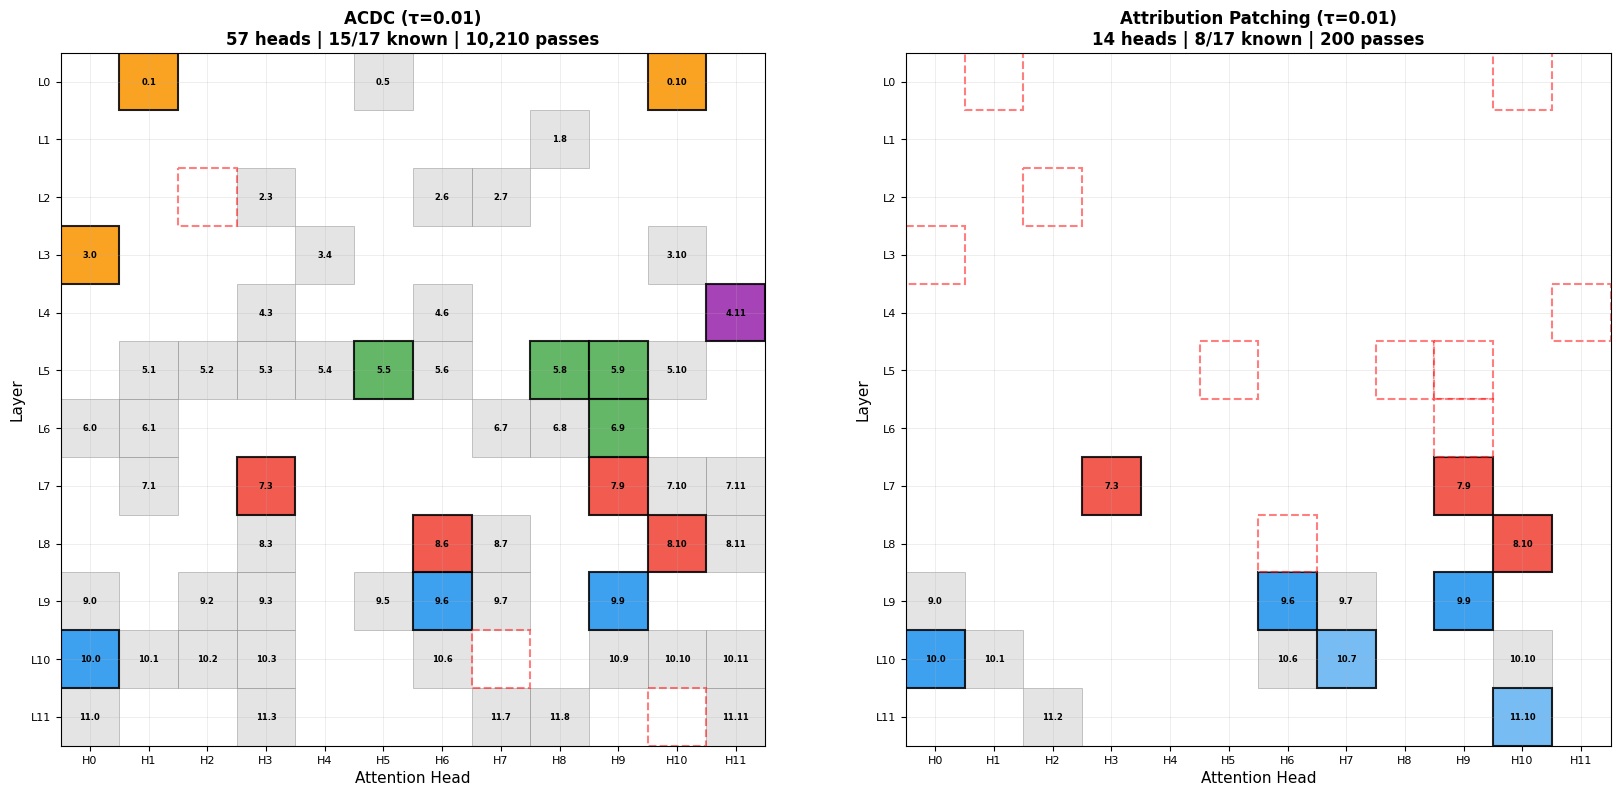

In [26]:
# ── Side by side comparison plot ──────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 9))

def draw_circuit_on_ax(ax, circuit, title, known_heads_dict):
    head_colors = {
        "name_movers":        "#2196F3",
        "backup_name_movers": "#64B5F6",
        "s_inhibition":       "#F44336",
        "induction":          "#4CAF50",
        "duplicate_token":    "#FF9800",
        "previous_token":     "#9C27B0",
    }

    grid = np.zeros((12, 12))
    ax.imshow(grid, cmap='Greys', aspect='auto',
              vmin=0, vmax=1, alpha=0.1)

    for (layer, head) in circuit:
        ax.add_patch(plt.Rectangle(
            (head-0.5, layer-0.5), 1, 1,
            facecolor='lightgrey', edgecolor='grey',
            linewidth=0.5, alpha=0.6
        ))

    for head_type, heads in known_heads_dict.items():
        color = head_colors.get(head_type, 'grey')
        for (l, h) in heads:
            if (l, h) in circuit:
                ax.add_patch(plt.Rectangle(
                    (h-0.5, l-0.5), 1, 1,
                    facecolor=color, edgecolor='black',
                    linewidth=1.5, alpha=0.85
                ))
            else:
                ax.add_patch(plt.Rectangle(
                    (h-0.5, l-0.5), 1, 1,
                    facecolor='white', edgecolor='red',
                    linewidth=1.5, linestyle='--', alpha=0.5
                ))

    for (layer, head) in circuit:
        ax.text(head, layer, f'{layer}.{head}',
                ha='center', va='center',
                fontsize=6, fontweight='bold')

    ax.set_xlim(-0.5, 11.5)
    ax.set_ylim(-0.5, 11.5)
    ax.set_xticks(range(12))
    ax.set_yticks(range(12))
    ax.set_xticklabels([f'H{i}' for i in range(12)], fontsize=8)
    ax.set_yticklabels([f'L{i}' for i in range(12)], fontsize=8)
    ax.set_xlabel('Attention Head', fontsize=11)
    ax.set_ylabel('Layer', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, linewidth=0.5)
    ax.invert_yaxis()

draw_circuit_on_ax(
    ax1, acdc_circuit_final,
    f"ACDC (τ=0.01)\n{len(acdc_circuit_final)} heads | "
    f"15/17 known | 10,210 passes",
    KNOWN_IOI_HEADS
)

draw_circuit_on_ax(
    ax2, ap_circuit_01,
    f"Attribution Patching (τ=0.01)\n{len(ap_circuit_01)} heads | "
    f"8/17 known | 200 passes",
    KNOWN_IOI_HEADS
)

# Shared legend
head_colors = {
    "Name Movers": "#2196F3",
    "Backup Name Movers": "#64B5F6",
    "S-Inhibition": "#F44336",
    "Induction": "#4CAF50",
    "Duplicate Token": "#FF9800",
    "Previous Token": "#9C27B0",
}
patches = [mpatches.Patch(color=c, label=l)
           for l, c in head_colors.items()]
patches.append(mpatches.Patch(color='lightgrey',
                               label='In circuit (unknown type)'))
patches.append(mpatches.Patch(facecolor='white', edgecolor='red',
                               linestyle='--',
                               label='Known head not recovered'))

fig.legend(handles=patches, loc='lower center',
           ncol=4, fontsize=9,
           bbox_to_anchor=(0.5, -0.05))

plt.suptitle("Circuit Comparison — GPT-2 Small IOI Task",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('data/results/circuit_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Comparison plot saved to data/results/circuit_comparison.png")

In [27]:
import subprocess
result = subprocess.run(['dot', '-V'], capture_output=True, text=True)
print(result.stderr)

dot - graphviz version 2.43.0 (0)



Saved to data/results/acdc_circuit_graph.png


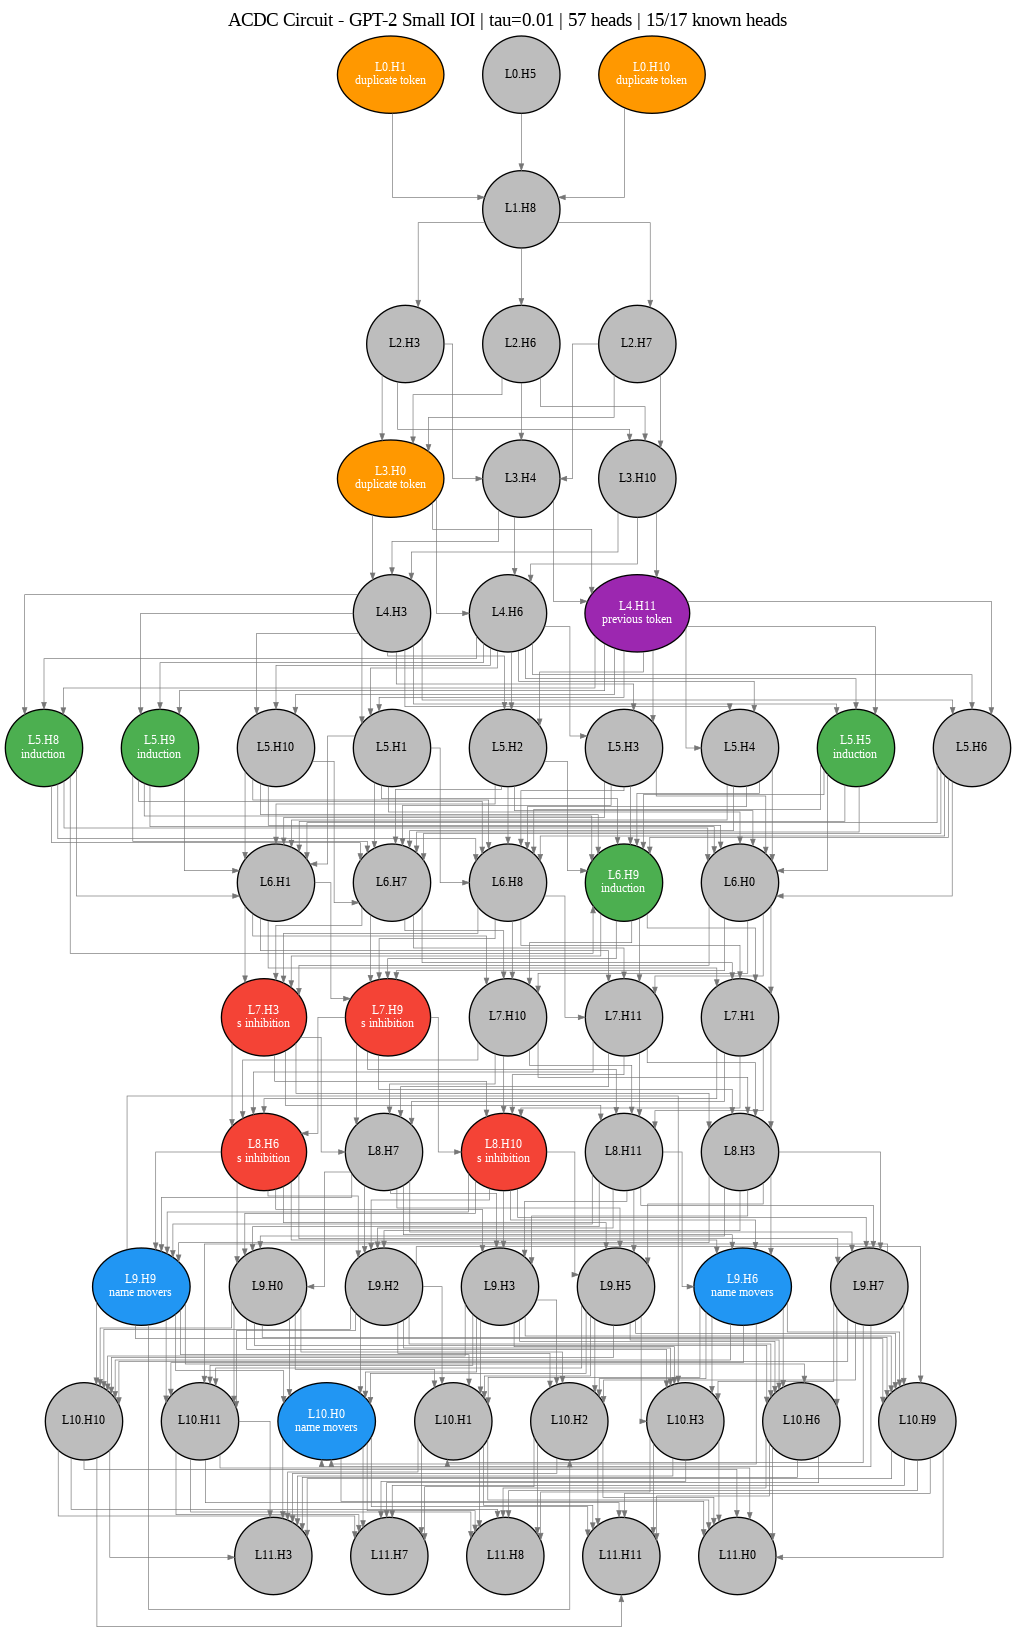

Saved to data/results/ap_circuit_graph.png


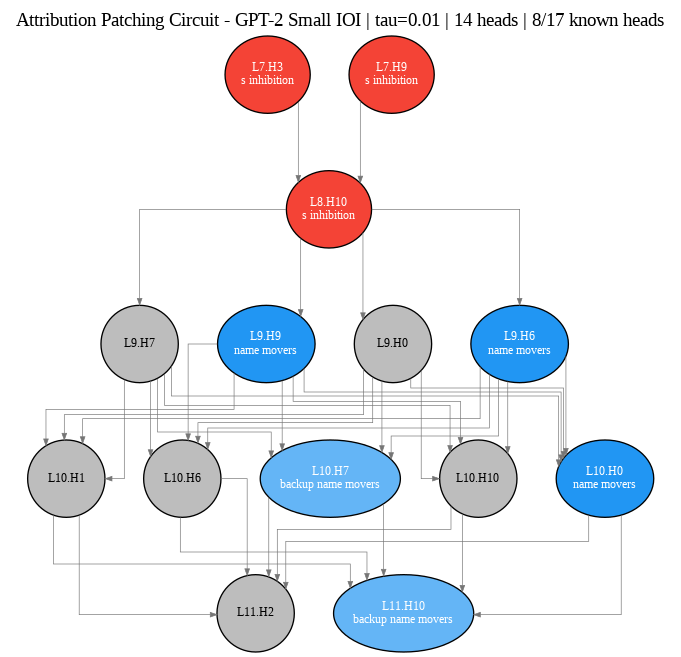

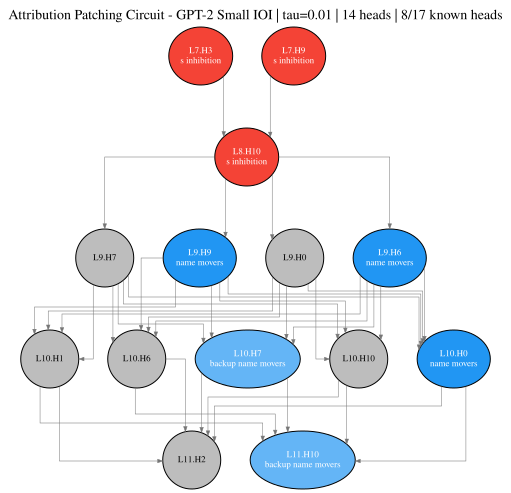

In [30]:
# ── Graphviz circuit diagram ───────────────────────────────────────────────
import graphviz

def plot_circuit_graphviz(circuit, title, known_heads_dict, filename):
    """
    Plot circuit as a directed graph using Graphviz.
    Nodes are (layer, head) pairs, colored by head type.
    Edges connect heads across layers.
    """
    head_colors = {
        "name_movers":        "#2196F3",
        "backup_name_movers": "#64B5F6",
        "s_inhibition":       "#F44336",
        "induction":          "#4CAF50",
        "duplicate_token":    "#FF9800",
        "previous_token":     "#9C27B0",
    }

    # Map each head to its type
    head_type_map = {}
    for head_type, heads in known_heads_dict.items():
        for (l, h) in heads:
            head_type_map[(l, h)] = head_type

    dot = graphviz.Digraph(
        comment=title,
        graph_attr={
            'rankdir': 'TB',
            'splines': 'ortho',
            'nodesep': '0.4',
            'ranksep': '0.6',
            'label': title,
            'fontsize': '14',
            'labelloc': 't'
        }
    )

    # Group nodes by layer using subgraphs
    circuit_list = sorted(circuit)
    layers_present = sorted(set(l for (l, h) in circuit_list))

    for layer in layers_present:
        with dot.subgraph() as s:
            s.attr(rank='same')
            layer_heads = [(l, h) for (l, h) in circuit_list if l == layer]
            for (l, h) in layer_heads:
                head_type = head_type_map.get((l, h), None)
                color = head_colors.get(head_type, '#BDBDBD')
                label = f"L{l}.H{h}"
                if head_type:
                    label += f"\n{head_type.replace('_', ' ')}"

                dot.node(
                    f"L{l}H{h}",
                    label=label,
                    shape='oval' if head_type else 'ellipse',
                    style='filled',
                    fillcolor=color,
                    fontcolor='white' if head_type else 'black',
                    fontsize='9',
                    width='0.8',
                    height='0.8'
                )

    # Add edges between consecutive layer heads in circuit
    for i, (l1, h1) in enumerate(circuit_list):
        for (l2, h2) in circuit_list:
            if l2 == l1 + 1:
                dot.edge(
                    f"L{l1}H{h1}",
                    f"L{l2}H{h2}",
                    color='#757575',
                    arrowsize='0.5',
                    penwidth='0.5'
                )

    dot.render(f'data/results/{filename}', format='png', cleanup=True)
    print(f"Saved to data/results/{filename}.png")

    # Display in notebook
    from IPython.display import Image, display
    display(Image(f'data/results/{filename}.png'))

    return dot

# Plot ACDC
plot_circuit_graphviz(
    circuit=acdc_circuit_final,
    title=f"ACDC Circuit - GPT-2 Small IOI | "
          f"tau=0.01 | {len(acdc_circuit_final)} heads | 15/17 known heads",
    known_heads_dict=KNOWN_IOI_HEADS,
    filename="acdc_circuit_graph"
)

# Plot AP
plot_circuit_graphviz(
    circuit=ap_circuit_01,
    title=f"Attribution Patching Circuit - GPT-2 Small IOI | "
          f"tau=0.01 | {len(ap_circuit_01)} heads | 8/17 known heads",
    known_heads_dict=KNOWN_IOI_HEADS,
    filename="ap_circuit_graph"
)